In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, BatchNormalization, Attention, Dropout, Dense, GlobalAveragePooling1D, Embedding, Reshape, Concatenate

C:\Users\hercd\AppData\Local\Temp\ipykernel_19312\2696667154.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


# Weather + Kwh Data from 01/01/2022 - 04/07/2024

In [2]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\hercd\AppData\Local\Temp\ipykernel_19312\592454515.py:1: SyntaxWarning: invalid escape sequence '\D'
  data = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\cleaned_data_csv.csv")


,Kwh,name,datetime,temp,feelslike,dew,humidity,precip,snow,snowdepth,...,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
0,0.0,"Kozani, Greece",2022-01-01 00:00:00,6.0,4.4,2.0,75.51,0.0,0.0,0.0,...,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
1,0.0,"Kozani, Greece",2022-01-01 01:00:00,6.0,5.0,2.0,75.51,0.0,0.0,0.0,...,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2,0.0,"Kozani, Greece",2022-01-01 02:00:00,4.9,3.2,2.0,81.61,0.0,NaN,0.0,...,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
3,0.0,"Kozani, Greece",2022-01-01 03:00:00,4.0,4.0,1.0,80.80,0.0,NaN,0.0,...,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
4,0.0,"Kozani, Greece",2022-01-01 04:00:00,3.0,1.6,2.0,93.14,0.0,NaN,0.0,...,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [3]:
data.isna().sum()

Kwh                   0
name                  0
datetime              0
temp                  0
feelslike             0
dew                   0
humidity              0
precip                0
snow                 53
snowdepth             0
windgust              0
windspeed             0
winddir               0
sealevelpressure      0
cloudcover            0
visibility          278
solarradiation        1
solarenergy           1
uvindex               1
conditions            0
icon                  0
dtype: int64

# Weather Data 2020 -2021

In [4]:
weather_2020_2021 = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\Kozani, Greece 2020-01-01 to 2021-12-31.csv") 
weather_2020_2021

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\hercd\AppData\Local\Temp\ipykernel_19312\1551896066.py:1: SyntaxWarning: invalid escape sequence '\D'
  weather_2020_2021 = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\Kozani, Greece 2020-01-01 to 2021-12-31.csv")


,name,datetime,temp,feelslike,dew,humidity,precip,precipprob,preciptype,snow,...,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,conditions,icon,stations
0,"Kozani, Greece",2020-01-01T00:00:00,0.0,0.0,-12.0,40.02,0.0,0,NaN,0.0,...,1024.0,45.3,NaN,0.0,0.0,0,NaN,Partially cloudy,partly-cloudy-night,"16632099999,LGKZ"
1,"Kozani, Greece",2020-01-01T01:00:00,1.0,1.0,-11.0,40.33,0.0,0,NaN,0.0,...,1023.0,94.1,NaN,0.0,0.0,0,NaN,Overcast,cloudy,"16632099999,LGKZ"
2,"Kozani, Greece",2020-01-01T02:00:00,2.0,0.5,-12.0,34.62,0.0,0,NaN,NaN,...,1026.2,99.0,NaN,0.0,0.0,0,NaN,Overcast,cloudy,"16632099999,LGKZ,16614099999"
3,"Kozani, Greece",2020-01-01T03:00:00,2.0,-0.8,-12.0,34.66,0.0,0,NaN,NaN,...,1023.0,98.4,NaN,0.0,0.0,0,NaN,Overcast,cloudy,"16632099999,LGKZ"
4,"Kozani, Greece",2020-01-01T04:00:00,2.0,2.0,-11.0,37.54,0.0,0,NaN,NaN,...,1022.0,95.2,NaN,0.0,0.0,0,NaN,Overcast,cloudy,"16632099999,LGKZ"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17539,"Kozani, Greece",2021-12-31T19:00:00,10.0,7.5,2.0,57.53,0.0,0,NaN,0.0,...,1023.0,3.4,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,LGKZ"
17540,"Kozani, Greece",2021-12-31T20:00:00,9.0,6.5,2.0,61.55,0.0,0,NaN,0.0,...,1023.0,2.6,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,16618199999,LGKZ,16614099999,16613..."
17541,"Kozani, Greece",2021-12-31T21:00:00,8.0,5.4,2.0,65.84,0.0,0,NaN,0.0,...,1023.0,1.8,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,LGKZ"
17542,"Kozani, Greece",2021-12-31T22:00:00,8.0,6.0,2.0,65.84,0.0,0,NaN,0.0,...,1023.0,0.0,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,LGKZ"


In [5]:
weather_2020_2021.isna().sum()

name                    0
datetime                0
temp                    0
feelslike               0
dew                     0
humidity                0
precip                  0
precipprob              0
preciptype          16865
snow                 3655
snowdepth               0
windgust                0
windspeed               0
winddir                 0
sealevelpressure        0
cloudcover              0
visibility          10473
solarradiation          0
solarenergy             0
uvindex                 0
severerisk          17544
conditions              0
icon                    0
stations                0
dtype: int64

# Kwh Data 2020 - 2021

In [6]:
kwh_2020 = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\Kwh_2020.csv", delimiter=',')
kwh_2020[['Date', 'Kwh']] = kwh_2020['Time'].str.split(',', expand=True)
kwh_2020 = kwh_2020[["Date", "Kwh"]]
kwh_2020['Kwh'] = pd.to_numeric(kwh_2020['Kwh'].str.strip('\"'))
kwh_2020.to_csv("energy.csv", index = False)
kwh_2020


<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\hercd\AppData\Local\Temp\ipykernel_19312\3396327368.py:1: SyntaxWarning: invalid escape sequence '\D'
  kwh_2020 = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\Kwh_2020.csv", delimiter=',')


,Date,Kwh
0,01/01/2020 08:00,0.0513
1,01/01/2020 09:00,0.2104
2,01/01/2020 10:00,0.3981
3,01/01/2020 11:00,0.5015
4,01/01/2020 12:00,0.5235
...,...,...
4603,30/12/2020 13:00,0.4383
4604,30/12/2020 14:00,0.2482
4605,30/12/2020 15:00,0.1042
4606,30/12/2020 16:00,0.0350


In [7]:
kwh_2021 = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\Kwh_2021.csv", delimiter=',')
kwh_2021[['Date', 'Kwh']] = kwh_2021['Time'].str.split(',', expand=True)
kwh_2021 = kwh_2021[["Date", "Kwh"]]
kwh_2021['Kwh'] = pd.to_numeric(kwh_2021['Kwh'].str.strip('\"'))
kwh_2021.to_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\Kwh_2021_processed.csv", index = False)
kwh_2021

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\D'
C:\Users\hercd\AppData\Local\Temp\ipykernel_19312\2953234458.py:1: SyntaxWarning: invalid escape sequence '\D'
  kwh_2021 = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\Kwh_2021.csv", delimiter=',')
C:\Users\hercd\AppData\Local\Temp\ipykernel_19312\2953234458.py:5: SyntaxWarning: invalid escape sequence '\D'
  kwh_2021.to_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\Kwh_2021_processed.csv", index = False)


,Date,Kwh
0,01/01/2021 08:00,0.0477
1,01/01/2021 09:00,0.2101
2,01/01/2021 10:00,0.3913
3,01/01/2021 11:00,0.4911
4,01/01/2021 12:00,0.5105
...,...,...
8212,31/12/2021 19:00,0.0000
8213,31/12/2021 20:00,0.0000
8214,31/12/2021 21:00,0.0000
8215,31/12/2021 22:00,0.0000


In [8]:
#kwh_2020.index = kwh_2020['Date']
#kwh_2021.index = kwh_2021['Date']

#kwh_2020.head(), kwh_2021.head()

In [9]:
kwh_2020.info, kwh_2020.info

(<bound method DataFrame.info of                   Date     Kwh
 0     01/01/2020 08:00  0.0513
 1     01/01/2020 09:00  0.2104
 2     01/01/2020 10:00  0.3981
 3     01/01/2020 11:00  0.5015
 4     01/01/2020 12:00  0.5235
 ...                ...     ...
 4603  30/12/2020 13:00  0.4383
 4604  30/12/2020 14:00  0.2482
 4605  30/12/2020 15:00  0.1042
 4606  30/12/2020 16:00  0.0350
 4607  30/12/2020 17:00  0.0000
 
 [4608 rows x 2 columns]>,
 <bound method DataFrame.info of                   Date     Kwh
 0     01/01/2020 08:00  0.0513
 1     01/01/2020 09:00  0.2104
 2     01/01/2020 10:00  0.3981
 3     01/01/2020 11:00  0.5015
 4     01/01/2020 12:00  0.5235
 ...                ...     ...
 4603  30/12/2020 13:00  0.4383
 4604  30/12/2020 14:00  0.2482
 4605  30/12/2020 15:00  0.1042
 4606  30/12/2020 16:00  0.0350
 4607  30/12/2020 17:00  0.0000
 
 [4608 rows x 2 columns]>)

In [10]:
energy_2020_2021 = pd.concat([kwh_2020, kwh_2021], axis= 0)
energy_2020_2021.head(10), energy_2020_2021.info

(               Date     Kwh
 0  01/01/2020 08:00  0.0513
 1  01/01/2020 09:00  0.2104
 2  01/01/2020 10:00  0.3981
 3  01/01/2020 11:00  0.5015
 4  01/01/2020 12:00  0.5235
 5  01/01/2020 13:00  0.4745
 6  01/01/2020 14:00  0.3588
 7  01/01/2020 15:00  0.2070
 8  01/01/2020 16:00  0.0642
 9  01/01/2020 17:00  0.0001,
 <bound method DataFrame.info of                   Date     Kwh
 0     01/01/2020 08:00  0.0513
 1     01/01/2020 09:00  0.2104
 2     01/01/2020 10:00  0.3981
 3     01/01/2020 11:00  0.5015
 4     01/01/2020 12:00  0.5235
 ...                ...     ...
 8212  31/12/2021 19:00  0.0000
 8213  31/12/2021 20:00  0.0000
 8214  31/12/2021 21:00  0.0000
 8215  31/12/2021 22:00  0.0000
 8216  31/12/2021 23:00  0.0000
 
 [12825 rows x 2 columns]>)

In [11]:
weather_2020_2021.tail(20)

,name,datetime,temp,feelslike,dew,humidity,precip,precipprob,preciptype,snow,...,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,conditions,icon,stations
17524,"Kozani, Greece",2021-12-31T04:00:00,5.0,0.8,1.0,75.34,0.0,0,NaN,NaN,...,1021.0,35.2,NaN,0.0,0.0,0,NaN,Partially cloudy,partly-cloudy-night,"16632099999,LGKZ"
17525,"Kozani, Greece",2021-12-31T05:00:00,5.0,0.8,0.0,70.10,0.0,0,NaN,NaN,...,1021.0,5.4,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,16618199999,LGKZ,16614099999,16613..."
17526,"Kozani, Greece",2021-12-31T06:00:00,5.0,0.6,0.0,70.09,0.0,0,NaN,NaN,...,1021.0,4.6,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,LGKZ"
17527,"Kozani, Greece",2021-12-31T07:00:00,5.0,0.4,0.0,70.09,0.0,0,NaN,0.0,...,1022.0,3.5,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,LGKZ"
17528,"Kozani, Greece",2021-12-31T08:00:00,5.0,0.6,0.0,70.12,0.0,0,NaN,0.0,...,1022.0,25.6,10.0,9.0,0.0,0,NaN,Partially cloudy,partly-cloudy-day,"16632099999,16618199999,LGKZ,F2557,16614099999..."
17529,"Kozani, Greece",2021-12-31T09:00:00,5.0,0.6,0.0,70.09,0.0,0,NaN,0.0,...,1023.0,25.7,10.0,45.0,0.2,0,NaN,Partially cloudy,partly-cloudy-day,"16632099999,LGKZ,F2557"
17530,"Kozani, Greece",2021-12-31T10:00:00,7.0,2.8,1.0,65.62,0.0,0,NaN,0.0,...,1024.0,25.7,10.0,157.0,0.6,2,NaN,Partially cloudy,partly-cloudy-day,"16632099999,LGKZ,F2557"
17531,"Kozani, Greece",2021-12-31T11:00:00,8.0,4.4,0.0,57.02,0.0,0,NaN,0.0,...,1024.0,25.7,10.0,296.0,1.1,3,NaN,Partially cloudy,partly-cloudy-day,"16632099999,16618199999,LGKZ,F2557,16614099999..."
17532,"Kozani, Greece",2021-12-31T12:00:00,9.0,5.5,0.0,53.28,0.0,0,NaN,0.0,...,1024.0,25.7,10.0,347.0,1.2,3,NaN,Partially cloudy,partly-cloudy-day,"16632099999,LGKZ,F2557"
17533,"Kozani, Greece",2021-12-31T13:00:00,10.0,7.3,0.0,49.82,0.0,0,NaN,0.0,...,1023.0,25.7,10.0,418.0,1.5,4,NaN,Partially cloudy,partly-cloudy-day,"16632099999,LGKZ,F2557"


In [12]:
energy_2020_2021

,Date,Kwh
0,01/01/2020 08:00,0.0513
1,01/01/2020 09:00,0.2104
2,01/01/2020 10:00,0.3981
3,01/01/2020 11:00,0.5015
4,01/01/2020 12:00,0.5235
...,...,...
8212,31/12/2021 19:00,0.0000
8213,31/12/2021 20:00,0.0000
8214,31/12/2021 21:00,0.0000
8215,31/12/2021 22:00,0.0000


# Merged Data 2020 - 2021

In [13]:
energy_2020_2021['Date'] = pd.to_datetime(energy_2020_2021['Date'], format = '%d/%m/%Y %H:%M')
weather_2020_2021['datetime'] = pd.to_datetime(weather_2020_2021['datetime'], format = '%Y-%m-%dT%H:%M:%S')
energy_2020_2021, weather_2020_2021

(                    Date     Kwh
 0    2020-01-01 08:00:00  0.0513
 1    2020-01-01 09:00:00  0.2104
 2    2020-01-01 10:00:00  0.3981
 3    2020-01-01 11:00:00  0.5015
 4    2020-01-01 12:00:00  0.5235
 ...                  ...     ...
 8212 2021-12-31 19:00:00  0.0000
 8213 2021-12-31 20:00:00  0.0000
 8214 2021-12-31 21:00:00  0.0000
 8215 2021-12-31 22:00:00  0.0000
 8216 2021-12-31 23:00:00  0.0000
 
 [12825 rows x 2 columns],
                  name            datetime  temp  feelslike   dew  humidity  \
 0      Kozani, Greece 2020-01-01 00:00:00   0.0        0.0 -12.0     40.02   
 1      Kozani, Greece 2020-01-01 01:00:00   1.0        1.0 -11.0     40.33   
 2      Kozani, Greece 2020-01-01 02:00:00   2.0        0.5 -12.0     34.62   
 3      Kozani, Greece 2020-01-01 03:00:00   2.0       -0.8 -12.0     34.66   
 4      Kozani, Greece 2020-01-01 04:00:00   2.0        2.0 -11.0     37.54   
 ...               ...                 ...   ...        ...   ...       ...   
 17539  Ko

In [14]:
kwh_weather_2020_2021 = pd.merge(energy_2020_2021, weather_2020_2021, left_on='Date', right_on='datetime', how='outer')
kwh_weather_2020_2021

,Date,Kwh,name,datetime,temp,feelslike,dew,humidity,precip,precipprob,...,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,conditions,icon,stations
0,NaT,NaN,"Kozani, Greece",2020-01-01 00:00:00,0.0,0.0,-12.0,40.02,0.0,0,...,1024.0,45.3,NaN,0.0,0.0,0,NaN,Partially cloudy,partly-cloudy-night,"16632099999,LGKZ"
1,NaT,NaN,"Kozani, Greece",2020-01-01 01:00:00,1.0,1.0,-11.0,40.33,0.0,0,...,1023.0,94.1,NaN,0.0,0.0,0,NaN,Overcast,cloudy,"16632099999,LGKZ"
2,NaT,NaN,"Kozani, Greece",2020-01-01 02:00:00,2.0,0.5,-12.0,34.62,0.0,0,...,1026.2,99.0,NaN,0.0,0.0,0,NaN,Overcast,cloudy,"16632099999,LGKZ,16614099999"
3,NaT,NaN,"Kozani, Greece",2020-01-01 03:00:00,2.0,-0.8,-12.0,34.66,0.0,0,...,1023.0,98.4,NaN,0.0,0.0,0,NaN,Overcast,cloudy,"16632099999,LGKZ"
4,NaT,NaN,"Kozani, Greece",2020-01-01 04:00:00,2.0,2.0,-11.0,37.54,0.0,0,...,1022.0,95.2,NaN,0.0,0.0,0,NaN,Overcast,cloudy,"16632099999,LGKZ"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17539,2021-12-31 19:00:00,0.0,"Kozani, Greece",2021-12-31 19:00:00,10.0,7.5,2.0,57.53,0.0,0,...,1023.0,3.4,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,LGKZ"
17540,2021-12-31 20:00:00,0.0,"Kozani, Greece",2021-12-31 20:00:00,9.0,6.5,2.0,61.55,0.0,0,...,1023.0,2.6,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,16618199999,LGKZ,16614099999,16613..."
17541,2021-12-31 21:00:00,0.0,"Kozani, Greece",2021-12-31 21:00:00,8.0,5.4,2.0,65.84,0.0,0,...,1023.0,1.8,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,LGKZ"
17542,2021-12-31 22:00:00,0.0,"Kozani, Greece",2021-12-31 22:00:00,8.0,6.0,2.0,65.84,0.0,0,...,1023.0,0.0,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,LGKZ"


In [15]:
kwh_weather_2020_2021.isna().sum()

Date                 4718
Kwh                  4718
name                    0
datetime                0
temp                    0
feelslike               0
dew                     0
humidity                0
precip                  0
precipprob              0
preciptype          16865
snow                 3655
snowdepth               0
windgust                0
windspeed               0
winddir                 0
sealevelpressure        0
cloudcover              0
visibility          10473
solarradiation          0
solarenergy             0
uvindex                 0
severerisk          17544
conditions              0
icon                    0
stations                0
dtype: int64

In [16]:
kwh_weather_2020_2021["Date"][pd.isna(kwh_weather_2020_2021["Date"])] = kwh_weather_2020_2021["datetime"][pd.isna(kwh_weather_2020_2021["Date"])]
kwh_weather_2020_2021

C:\Users\hercd\AppData\Local\Temp\ipykernel_19312\832488526.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  kwh_weather_2020_2021["Date"][pd.isna(kwh_weather_2020_2021["Date"])] = kwh_weather_2020_2021["datetime"][pd.isna(kwh_weather_202

,Date,Kwh,name,datetime,temp,feelslike,dew,humidity,precip,precipprob,...,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,conditions,icon,stations
0,2020-01-01 00:00:00,NaN,"Kozani, Greece",2020-01-01 00:00:00,0.0,0.0,-12.0,40.02,0.0,0,...,1024.0,45.3,NaN,0.0,0.0,0,NaN,Partially cloudy,partly-cloudy-night,"16632099999,LGKZ"
1,2020-01-01 01:00:00,NaN,"Kozani, Greece",2020-01-01 01:00:00,1.0,1.0,-11.0,40.33,0.0,0,...,1023.0,94.1,NaN,0.0,0.0,0,NaN,Overcast,cloudy,"16632099999,LGKZ"
2,2020-01-01 02:00:00,NaN,"Kozani, Greece",2020-01-01 02:00:00,2.0,0.5,-12.0,34.62,0.0,0,...,1026.2,99.0,NaN,0.0,0.0,0,NaN,Overcast,cloudy,"16632099999,LGKZ,16614099999"
3,2020-01-01 03:00:00,NaN,"Kozani, Greece",2020-01-01 03:00:00,2.0,-0.8,-12.0,34.66,0.0,0,...,1023.0,98.4,NaN,0.0,0.0,0,NaN,Overcast,cloudy,"16632099999,LGKZ"
4,2020-01-01 04:00:00,NaN,"Kozani, Greece",2020-01-01 04:00:00,2.0,2.0,-11.0,37.54,0.0,0,...,1022.0,95.2,NaN,0.0,0.0,0,NaN,Overcast,cloudy,"16632099999,LGKZ"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17539,2021-12-31 19:00:00,0.0,"Kozani, Greece",2021-12-31 19:00:00,10.0,7.5,2.0,57.53,0.0,0,...,1023.0,3.4,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,LGKZ"
17540,2021-12-31 20:00:00,0.0,"Kozani, Greece",2021-12-31 20:00:00,9.0,6.5,2.0,61.55,0.0,0,...,1023.0,2.6,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,16618199999,LGKZ,16614099999,16613..."
17541,2021-12-31 21:00:00,0.0,"Kozani, Greece",2021-12-31 21:00:00,8.0,5.4,2.0,65.84,0.0,0,...,1023.0,1.8,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,LGKZ"
17542,2021-12-31 22:00:00,0.0,"Kozani, Greece",2021-12-31 22:00:00,8.0,6.0,2.0,65.84,0.0,0,...,1023.0,0.0,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,LGKZ"


In [17]:
kwh_weather_2020_2021["Kwh"] = kwh_weather_2020_2021["Kwh"].fillna(0)
kwh_weather_2020_2021

,Date,Kwh,name,datetime,temp,feelslike,dew,humidity,precip,precipprob,...,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,conditions,icon,stations
0,2020-01-01 00:00:00,0.0,"Kozani, Greece",2020-01-01 00:00:00,0.0,0.0,-12.0,40.02,0.0,0,...,1024.0,45.3,NaN,0.0,0.0,0,NaN,Partially cloudy,partly-cloudy-night,"16632099999,LGKZ"
1,2020-01-01 01:00:00,0.0,"Kozani, Greece",2020-01-01 01:00:00,1.0,1.0,-11.0,40.33,0.0,0,...,1023.0,94.1,NaN,0.0,0.0,0,NaN,Overcast,cloudy,"16632099999,LGKZ"
2,2020-01-01 02:00:00,0.0,"Kozani, Greece",2020-01-01 02:00:00,2.0,0.5,-12.0,34.62,0.0,0,...,1026.2,99.0,NaN,0.0,0.0,0,NaN,Overcast,cloudy,"16632099999,LGKZ,16614099999"
3,2020-01-01 03:00:00,0.0,"Kozani, Greece",2020-01-01 03:00:00,2.0,-0.8,-12.0,34.66,0.0,0,...,1023.0,98.4,NaN,0.0,0.0,0,NaN,Overcast,cloudy,"16632099999,LGKZ"
4,2020-01-01 04:00:00,0.0,"Kozani, Greece",2020-01-01 04:00:00,2.0,2.0,-11.0,37.54,0.0,0,...,1022.0,95.2,NaN,0.0,0.0,0,NaN,Overcast,cloudy,"16632099999,LGKZ"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17539,2021-12-31 19:00:00,0.0,"Kozani, Greece",2021-12-31 19:00:00,10.0,7.5,2.0,57.53,0.0,0,...,1023.0,3.4,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,LGKZ"
17540,2021-12-31 20:00:00,0.0,"Kozani, Greece",2021-12-31 20:00:00,9.0,6.5,2.0,61.55,0.0,0,...,1023.0,2.6,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,16618199999,LGKZ,16614099999,16613..."
17541,2021-12-31 21:00:00,0.0,"Kozani, Greece",2021-12-31 21:00:00,8.0,5.4,2.0,65.84,0.0,0,...,1023.0,1.8,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,LGKZ"
17542,2021-12-31 22:00:00,0.0,"Kozani, Greece",2021-12-31 22:00:00,8.0,6.0,2.0,65.84,0.0,0,...,1023.0,0.0,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,LGKZ"


In [18]:
kwh_weather_2020_2021.isna().sum()

Date                    0
Kwh                     0
name                    0
datetime                0
temp                    0
feelslike               0
dew                     0
humidity                0
precip                  0
precipprob              0
preciptype          16865
snow                 3655
snowdepth               0
windgust                0
windspeed               0
winddir                 0
sealevelpressure        0
cloudcover              0
visibility          10473
solarradiation          0
solarenergy             0
uvindex                 0
severerisk          17544
conditions              0
icon                    0
stations                0
dtype: int64

In [19]:
kwh_weather_2020_2021 = kwh_weather_2020_2021.drop('Date', axis= 1)
kwh_weather_2020_2021

,Kwh,name,datetime,temp,feelslike,dew,humidity,precip,precipprob,preciptype,...,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,conditions,icon,stations
0,0.0,"Kozani, Greece",2020-01-01 00:00:00,0.0,0.0,-12.0,40.02,0.0,0,NaN,...,1024.0,45.3,NaN,0.0,0.0,0,NaN,Partially cloudy,partly-cloudy-night,"16632099999,LGKZ"
1,0.0,"Kozani, Greece",2020-01-01 01:00:00,1.0,1.0,-11.0,40.33,0.0,0,NaN,...,1023.0,94.1,NaN,0.0,0.0,0,NaN,Overcast,cloudy,"16632099999,LGKZ"
2,0.0,"Kozani, Greece",2020-01-01 02:00:00,2.0,0.5,-12.0,34.62,0.0,0,NaN,...,1026.2,99.0,NaN,0.0,0.0,0,NaN,Overcast,cloudy,"16632099999,LGKZ,16614099999"
3,0.0,"Kozani, Greece",2020-01-01 03:00:00,2.0,-0.8,-12.0,34.66,0.0,0,NaN,...,1023.0,98.4,NaN,0.0,0.0,0,NaN,Overcast,cloudy,"16632099999,LGKZ"
4,0.0,"Kozani, Greece",2020-01-01 04:00:00,2.0,2.0,-11.0,37.54,0.0,0,NaN,...,1022.0,95.2,NaN,0.0,0.0,0,NaN,Overcast,cloudy,"16632099999,LGKZ"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17539,0.0,"Kozani, Greece",2021-12-31 19:00:00,10.0,7.5,2.0,57.53,0.0,0,NaN,...,1023.0,3.4,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,LGKZ"
17540,0.0,"Kozani, Greece",2021-12-31 20:00:00,9.0,6.5,2.0,61.55,0.0,0,NaN,...,1023.0,2.6,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,16618199999,LGKZ,16614099999,16613..."
17541,0.0,"Kozani, Greece",2021-12-31 21:00:00,8.0,5.4,2.0,65.84,0.0,0,NaN,...,1023.0,1.8,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,LGKZ"
17542,0.0,"Kozani, Greece",2021-12-31 22:00:00,8.0,6.0,2.0,65.84,0.0,0,NaN,...,1023.0,0.0,NaN,0.0,0.0,0,NaN,Clear,clear-night,"16632099999,LGKZ"


In [20]:
kwh_weather_2020_2021.to_csv("cleaned_data_2020_2021.csv", index= False)

In [21]:
more_data_df = pd.concat([kwh_weather_2020_2021, data], axis= 0)

In [22]:
more_data_df

,Kwh,name,datetime,temp,feelslike,dew,humidity,precip,precipprob,preciptype,...,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,conditions,icon,stations
0,0.0000,"Kozani, Greece",2020-01-01 00:00:00,0.0,0.0,-12.0,40.02,0.0,0.0,NaN,...,1024.0,45.3,NaN,0.0,0.0,0.0,NaN,Partially cloudy,partly-cloudy-night,"16632099999,LGKZ"
1,0.0000,"Kozani, Greece",2020-01-01 01:00:00,1.0,1.0,-11.0,40.33,0.0,0.0,NaN,...,1023.0,94.1,NaN,0.0,0.0,0.0,NaN,Overcast,cloudy,"16632099999,LGKZ"
2,0.0000,"Kozani, Greece",2020-01-01 02:00:00,2.0,0.5,-12.0,34.62,0.0,0.0,NaN,...,1026.2,99.0,NaN,0.0,0.0,0.0,NaN,Overcast,cloudy,"16632099999,LGKZ,16614099999"
3,0.0000,"Kozani, Greece",2020-01-01 03:00:00,2.0,-0.8,-12.0,34.66,0.0,0.0,NaN,...,1023.0,98.4,NaN,0.0,0.0,0.0,NaN,Overcast,cloudy,"16632099999,LGKZ"
4,0.0000,"Kozani, Greece",2020-01-01 04:00:00,2.0,2.0,-11.0,37.54,0.0,0.0,NaN,...,1022.0,95.2,NaN,0.0,0.0,0.0,NaN,Overcast,cloudy,"16632099999,LGKZ"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21978,0.0592,"Kozani, Greece",2024-07-04 19:00:00,24.0,24.0,10.0,41.15,0.0,NaN,NaN,...,1010.0,79.3,NaN,207.0,0.7,2.0,NaN,Partially cloudy,partly-cloudy-day,NaN
21979,0.0085,"Kozani, Greece",2024-07-04 20:00:00,23.0,23.0,9.0,40.87,0.1,NaN,NaN,...,1010.0,81.7,NaN,103.0,0.4,1.0,NaN,"Rain, Partially cloudy",rain,NaN
21980,0.0000,"Kozani, Greece",2024-07-04 21:00:00,21.0,21.0,10.0,49.39,0.1,NaN,NaN,...,1011.0,63.7,NaN,9.0,0.0,0.0,NaN,"Rain, Partially cloudy",rain,NaN
21981,0.0000,"Kozani, Greece",2024-07-04 22:00:00,20.0,20.0,11.0,56.15,0.0,NaN,NaN,...,1012.0,65.5,NaN,0.0,0.0,0.0,NaN,Partially cloudy,partly-cloudy-night,NaN


In [23]:
cleaned_data_new = more_data_df.drop(["severerisk", "preciptype", "precipprob", "stations"],axis= 1)
cleaned_data_new

,Kwh,name,datetime,temp,feelslike,dew,humidity,precip,snow,snowdepth,...,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
0,0.0000,"Kozani, Greece",2020-01-01 00:00:00,0.0,0.0,-12.0,40.02,0.0,0.0,0.0,...,3.6,292.9,1024.0,45.3,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
1,0.0000,"Kozani, Greece",2020-01-01 01:00:00,1.0,1.0,-11.0,40.33,0.0,0.0,0.0,...,1.8,300.4,1023.0,94.1,NaN,0.0,0.0,0.0,Overcast,cloudy
2,0.0000,"Kozani, Greece",2020-01-01 02:00:00,2.0,0.5,-12.0,34.62,0.0,NaN,0.0,...,5.4,293.6,1026.2,99.0,NaN,0.0,0.0,0.0,Overcast,cloudy
3,0.0000,"Kozani, Greece",2020-01-01 03:00:00,2.0,-0.8,-12.0,34.66,0.0,NaN,0.0,...,9.4,270.0,1023.0,98.4,NaN,0.0,0.0,0.0,Overcast,cloudy
4,0.0000,"Kozani, Greece",2020-01-01 04:00:00,2.0,2.0,-11.0,37.54,0.0,NaN,0.0,...,3.6,298.2,1022.0,95.2,NaN,0.0,0.0,0.0,Overcast,cloudy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21978,0.0592,"Kozani, Greece",2024-07-04 19:00:00,24.0,24.0,10.0,41.15,0.0,0.0,0.0,...,9.4,180.0,1010.0,79.3,NaN,207.0,0.7,2.0,Partially cloudy,partly-cloudy-day
21979,0.0085,"Kozani, Greece",2024-07-04 20:00:00,23.0,23.0,9.0,40.87,0.1,0.0,0.0,...,3.6,172.8,1010.0,81.7,NaN,103.0,0.4,1.0,"Rain, Partially cloudy",rain
21980,0.0000,"Kozani, Greece",2024-07-04 21:00:00,21.0,21.0,10.0,49.39,0.1,0.0,0.0,...,0.0,0.0,1011.0,63.7,NaN,9.0,0.0,0.0,"Rain, Partially cloudy",rain
21981,0.0000,"Kozani, Greece",2024-07-04 22:00:00,20.0,20.0,11.0,56.15,0.0,0.0,0.0,...,0.0,0.0,1012.0,65.5,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [24]:
cleaned_data_new.isna().sum()

Kwh                     0
name                    0
datetime                0
temp                    0
feelslike               0
dew                     0
humidity                0
precip                  0
snow                 3708
snowdepth               0
windgust                0
windspeed               0
winddir                 0
sealevelpressure        0
cloudcover              0
visibility          10751
solarradiation          1
solarenergy             1
uvindex                 1
conditions              0
icon                    0
dtype: int64

In [25]:
cleaned_data_new.to_csv("cleaned_data_new_csv.csv", index= False)

In [37]:
cleaned_data_new.shape, data.shape

((39527, 21), (21983, 21))

# Analysis

In [26]:
kwh_weather_2020_2021.index = kwh_weather_2020_2021['datetime']

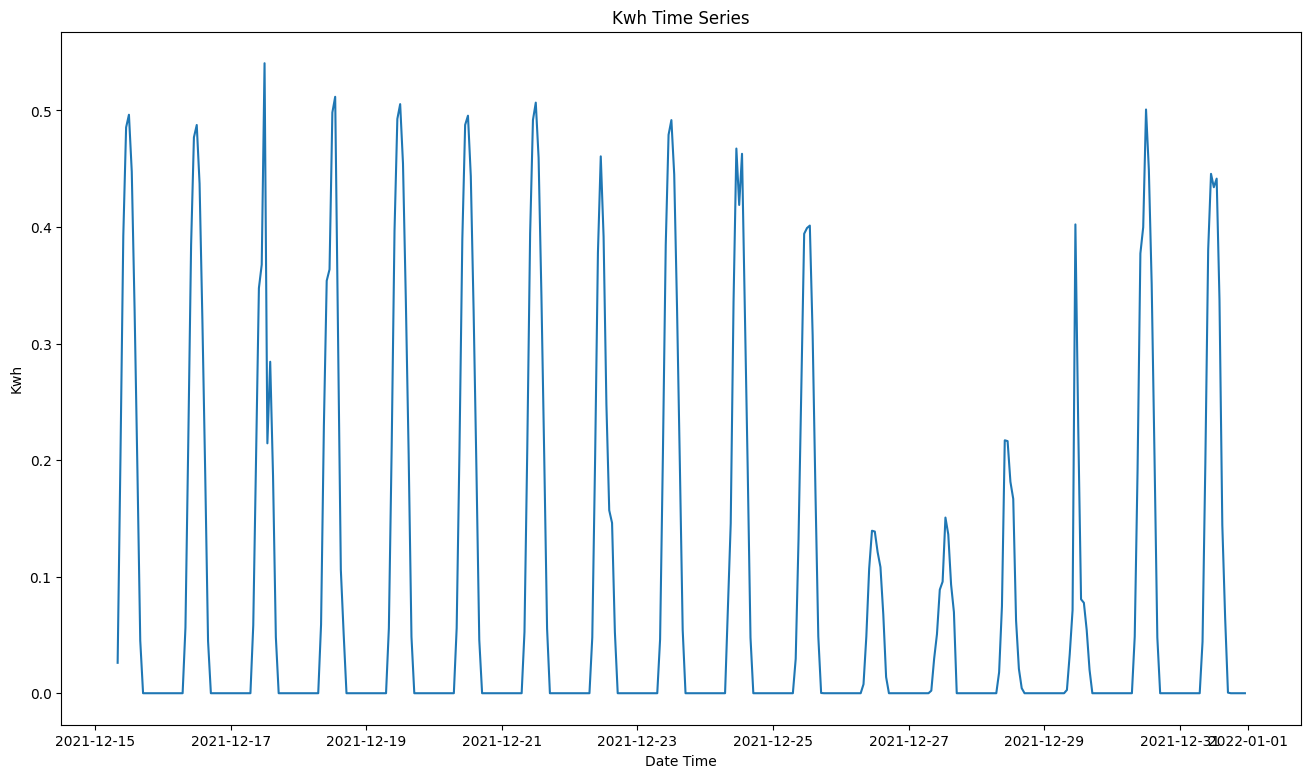

In [27]:
plt.figure(figsize= (16, 9))
sns.lineplot(x = kwh_weather_2020_2021.index[-400:], y = kwh_weather_2020_2021['Kwh'][-400:])
plt.xlabel("Date Time")
plt.ylabel("Kwh")
plt.title("Kwh Time Series")
plt.show()

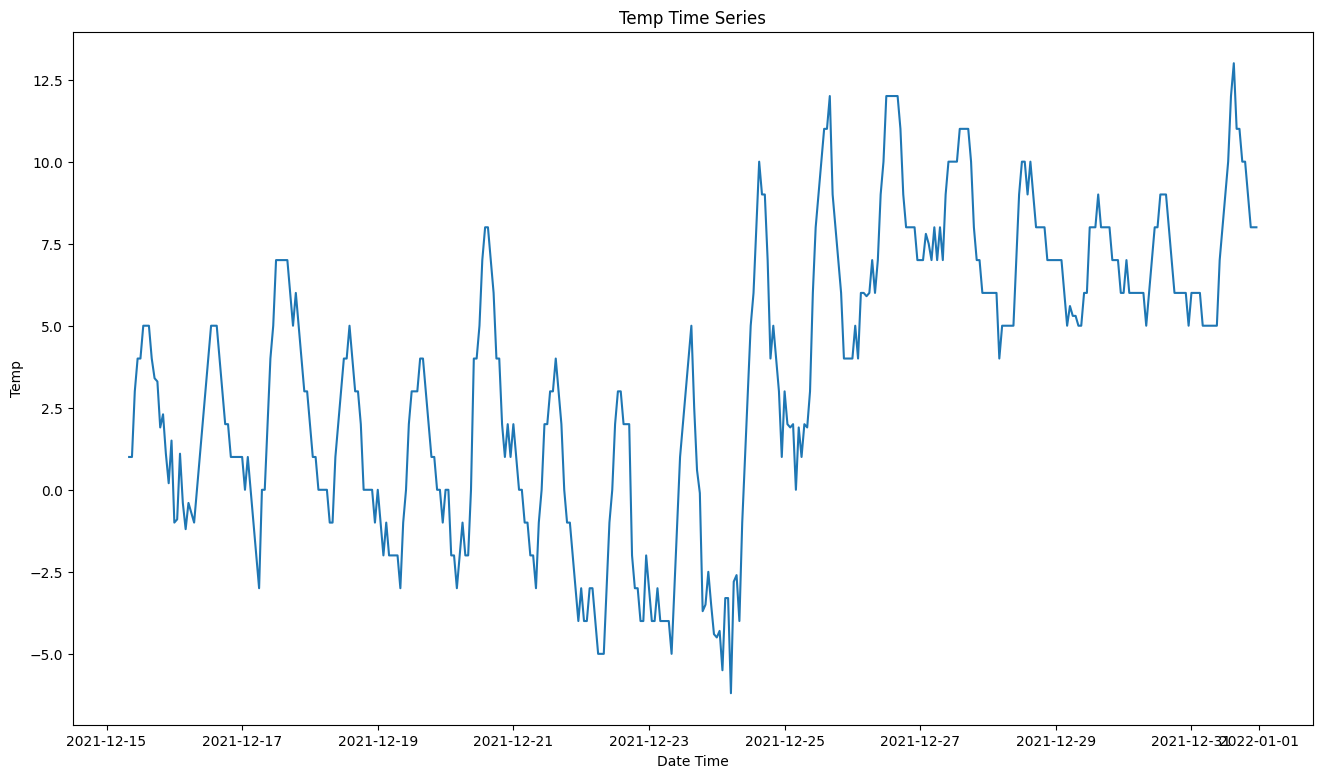

In [28]:
plt.figure(figsize= (16, 9))
sns.lineplot(x = kwh_weather_2020_2021.index[-400:], y = kwh_weather_2020_2021['temp'][-400:])
plt.xlabel("Date Time")
plt.ylabel("Temp")
plt.title("Temp Time Series")
plt.show()

In [29]:
tc = kwh_weather_2020_2021[["Kwh", "temp", "feelslike", "dew", "humidity", "windspeed", "winddir", "sealevelpressure", "cloudcover", "solarradiation", "solarenergy", "visibility", "snow", "snowdepth", "windgust", "uvindex"]].corr()

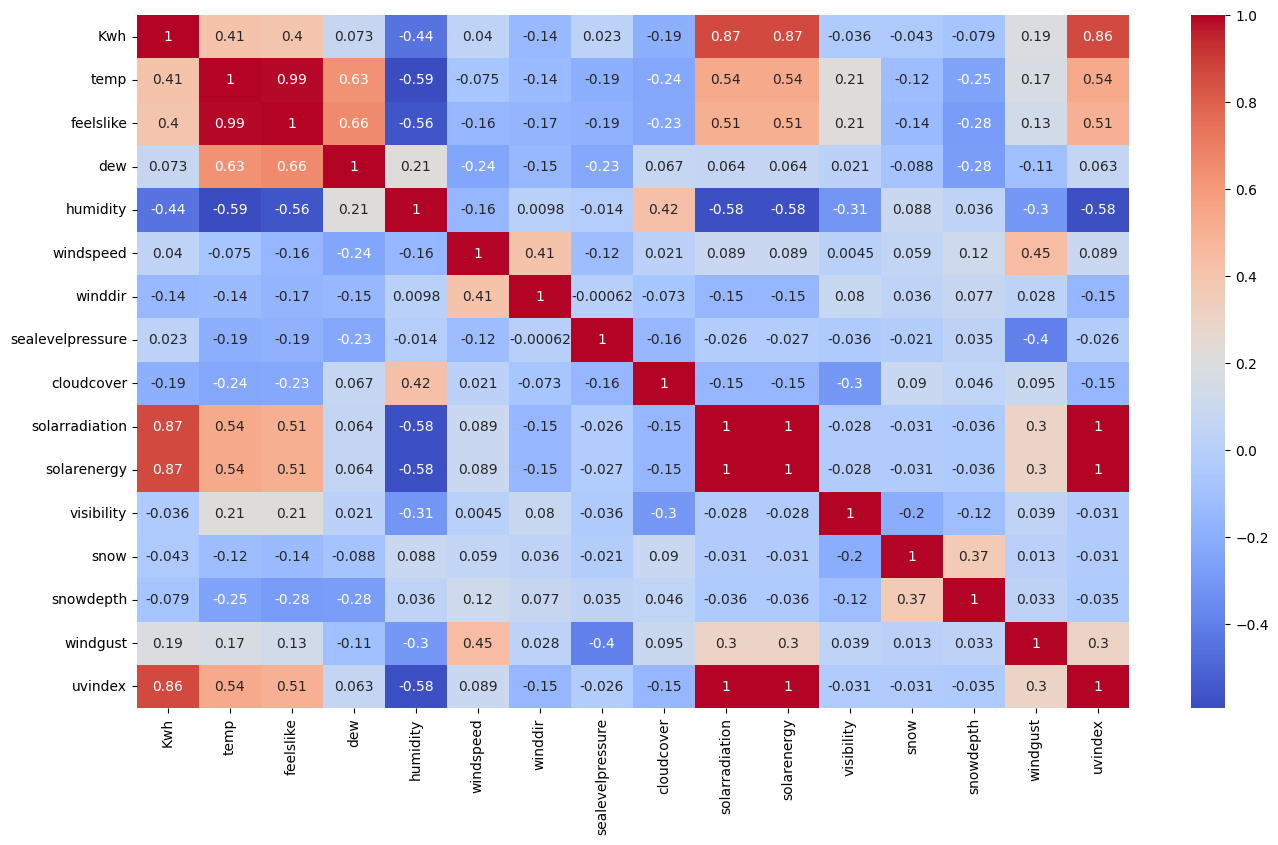

In [30]:
plt.figure(figsize= (16, 9))
sns.heatmap(tc, annot= True, cmap = "coolwarm")
plt.show()

In [31]:
kwh_data = kwh_weather_2020_2021[['temp', 'humidity', 'windgust', 'winddir', 'cloudcover', 'solarradiation', 'conditions']]
kwh_data

,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions
datetime,,,,,,,
2020-01-01 00:00:00,0.0,40.02,23.0,292.9,45.3,0.0,Partially cloudy
2020-01-01 01:00:00,1.0,40.33,23.4,300.4,94.1,0.0,Overcast
2020-01-01 02:00:00,2.0,34.62,22.2,293.6,99.0,0.0,Overcast
2020-01-01 03:00:00,2.0,34.66,23.0,270.0,98.4,0.0,Overcast
2020-01-01 04:00:00,2.0,37.54,24.8,298.2,95.2,0.0,Overcast
...,...,...,...,...,...,...,...
2021-12-31 19:00:00,10.0,57.53,21.2,340.0,3.4,0.0,Clear
2021-12-31 20:00:00,9.0,61.55,21.2,330.0,2.6,0.0,Clear
2021-12-31 21:00:00,8.0,65.84,22.7,300.0,1.8,0.0,Clear


In [32]:
kwh_data_new = cleaned_data_new[['temp', 'humidity', 'windgust', 'winddir', 'cloudcover', 'solarradiation', 'conditions']]


In [33]:
kwh_data.describe()

,temp,humidity,windgust,winddir,cloudcover,solarradiation
count,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000,17544.000000
mean,13.386810,58.974648,21.061862,215.312580,43.865612,180.160231
std,8.933937,23.022205,9.950691,131.605224,35.439575,261.499275
min,-10.000000,6.520000,0.000000,0.000000,0.000000,0.000000
25%,6.900000,40.590000,14.000000,110.000000,10.000000,0.000000
50%,12.000000,57.420000,19.100000,260.000000,34.400000,12.000000
75%,20.000000,76.680000,25.900000,340.000000,80.700000,319.000000
max,39.000000,100.000000,74.200000,360.000000,100.000000,1012.000000


# Test for equal Mean and Var of the 2 Datasets 

In [34]:
from scipy import stats
a = 0.05

for i in ["Kwh", "temp", "humidity", "winddir", "cloudcover", "solarradiation", "windgust"]:
    t_statistic, p_value = stats.ttest_ind(data[i], cleaned_data_new[i])

    lev_statistic, lev_p_value = stats.levene(data[i], cleaned_data_new[i])

    print(f" T Statistic of {i} = {round(t_statistic, 4)} \n P-Value of {i} = {round(p_value, 4)} \n Lev Statistic of {i} = {round(lev_statistic, 4)} \n Lev P-Value of {i}= {round(lev_p_value, 4)} ")
    
    if p_value < a:
        print(f" Reject the null hypothesis: Means of {i} are significantly different. ")
    else:
        print(f" Fail to reject the null hypothesis: No significant difference in means of {i}. ")
        
    if lev_p_value < a:
        print(f" Reject the null hypothesis: Variances of {i} are significantly different. \n \n")
    else:
        print(f" Fail to reject the null hypothesis: No significant difference in variances of {i}. \n \n ")

 T Statistic of Kwh = -0.0708 
 P-Value of Kwh = 0.9436 
 Lev Statistic of Kwh = 0.0049 
 Lev P-Value of Kwh= 0.9442 
 Fail to reject the null hypothesis: No significant difference in means of Kwh. 
 Fail to reject the null hypothesis: No significant difference in variances of Kwh. 
 
 
 T Statistic of temp = -0.193 
 P-Value of temp = 0.847 
 Lev Statistic of temp = 5.6594 
 Lev P-Value of temp= 0.0174 
 Fail to reject the null hypothesis: No significant difference in means of temp. 
 Reject the null hypothesis: Variances of temp are significantly different. 
 

 T Statistic of humidity = -3.3021 
 P-Value of humidity = 0.001 
 Lev Statistic of humidity = 1.634 
 Lev P-Value of humidity= 0.2012 
 Reject the null hypothesis: Means of humidity are significantly different. 
 Fail to reject the null hypothesis: No significant difference in variances of humidity. 
 
 
 T Statistic of winddir = -1.1564 
 P-Value of winddir = 0.2475 
 Lev Statistic of winddir = 0.2337 
 Lev P-Value of winddi